# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [4]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [4]:
df.head(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,month_year
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2,2011-01
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3,2011-01
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4,2011-01


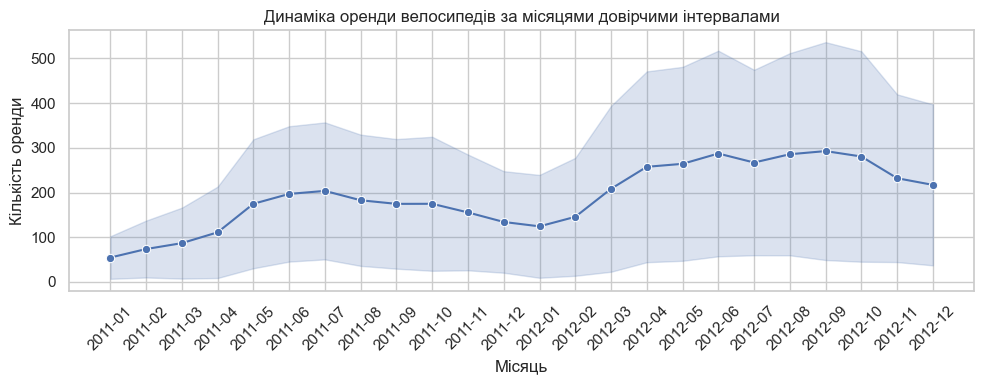

In [32]:
plt.figure(figsize=(10, 4))

sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o')
plt.title('Динаміка оренди велосипедів за місяцями довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)
plt.tight_layout();

Hайбільша невизначеність в даних у літні місяці

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

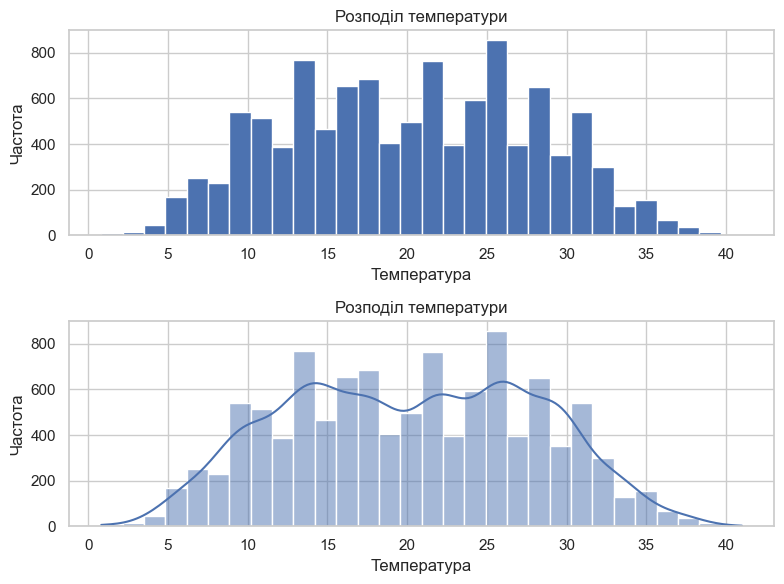

In [48]:
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
df.temp.plot.hist(bins=30)
plt.title('Розподіл температури')
plt.xlabel('Температура')
plt.ylabel('Частота')

plt.subplot(2, 1, 2)
sns.histplot(df.temp, bins=30, kde=True)
plt.title('Розподіл температури')
plt.xlabel('Температура')
plt.ylabel('Частота')

plt.tight_layout();

1. Візуальна різниця між Pandas та Seaborn тільки а прозорості і відстані між бінами
2. Додаткова лінія на графіку в Seaborn згладжує щільність розподілу поверх гістограми.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

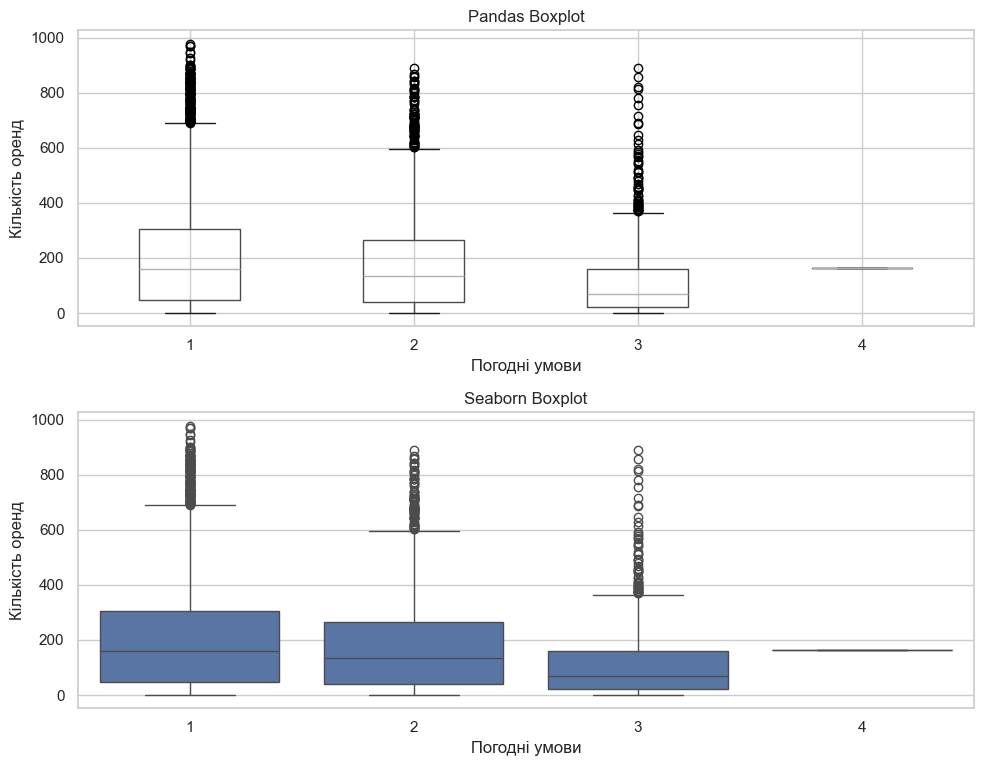

In [79]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

df.boxplot(column='count', by='weather', ax=axes[0])
axes[0].set_title('Pandas Boxplot')
axes[0].set_xlabel('Погодні умови')
axes[0].set_ylabel('Кількість оренд')
fig.suptitle('')

sns.boxplot(data=df, x='weather', y='count', ax=axes[1])
axes[1].set_title('Seaborn Boxplot')
axes[1].set_xlabel('Погодні умови')
axes[1].set_ylabel('Кількість оренд')

plt.tight_layout()
plt.show()


Візуально Seaborn boxplot виглядає більш сучасно при однакових налаштуваннях "коробки" мають більший маштаб і зафарбовані кольором

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [85]:
correlation = df[['temp', 'atemp', 'humidity', 'casual', 'registered','count']].corr()

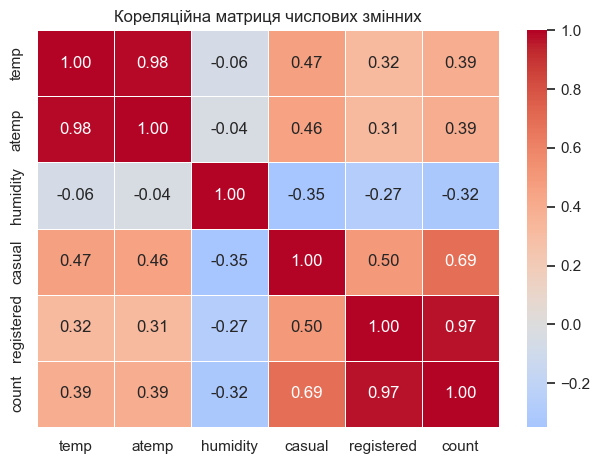

In [113]:
sns.heatmap(correlation,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    center=0,            
    linewidths=0.5
)

plt.title("Кореляційна матриця числових змінних")
plt.tight_layout()
plt.show();

1. Найсильніше з count пов’язана registered
2. Між temp та atemp позитивна кореляція, тому що фактично це трансформація тієї ж змінної, вони майже дублюють одна одну.
3. Humidity має негативну кореляцію casual, registered, count. Чим вища вологість, тим менше оренд.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


In [2]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='month_year', y='count')
plt.xticks(rotation=45)
plt.title("Розподіл оренди за кварталами")
plt.tight_layout()
plt.show();
plt.show()

NameError: name 'plt' is not defined

1. Товщина показує щільність розподілу, чим ширша товщина,тим більше спостережень у цьому діапазоні значень.
2. В 3 кварталі 2012 році найбільша варіабельність оренди (великий вертикальний діапазон).Це пік сезону,сильні коливання попиту.
3. Violin plot інформативніший, бо показує форму розподілу.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

In [1]:
df['month_year'] = pd.to_datetime(df['date']).dt.quarter
sample_df = df[['temp', 'humidity', 'windspeed', 'count']]
sns.pairplot(sample_df,  hue='month_year', diag_kind='kde')
plt.suptitle('Взаємозв\'язки між ключовими змінними', y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

1. Між temp та count спостерігається найсильніший лінійний зв'язок (з ростом температури - зростає кількість оренд).
2. temp найбільше відрізняється між кварталами (сезонність дуже чітка).

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

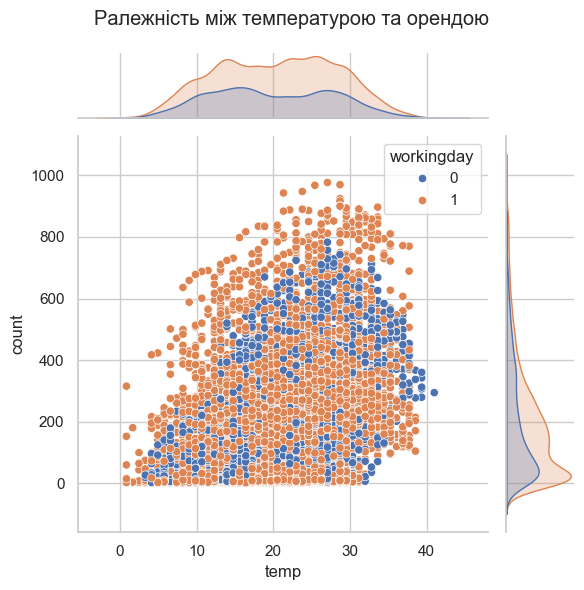

In [125]:
sns.jointplot(data=df, x="temp", y="count", hue="workingday")
plt.suptitle('Pалежність між температурою та орендою')
plt.tight_layout()
plt.show()

In [ ]:
1. Графіки по края показують розподіл (температури та кількості оренд) та різницю між робочими і неробочими днями.
2. В робочі дні більше точок з високими значеннями у вихідні більше середніх значень. 
    Кількість оренд зростає з температурою як у робочі, так і у неробочі дні. 